# Day 9: Exploratory Data Analysis (EDA)

**Intern:** Shri Sanjaykumar V  
**Role:** AI/ML Intern | **Organization:** Linkific  
**Curriculum Focus:** Exploratory Data Analysis, Descriptive Statistics, and Pattern Recognition  
**Environment:** Python 3.14.3 | Pandas 3.0.3 | NumPy 2.5.0 | Matplotlib 3.11.0 | Seaborn 0.13.2  

---

### 🎯 Learning Objectives
1. **Explore datasets before training models:** Conduct comprehensive schema discovery, statistical profiling, and distribution checks on cleaned data.
2. **Understand patterns and relationships in data:** Surface multivariate correlations, structural imbalances, central tendencies, and historical trajectories.

---

### 💻 Analysis Methodology Enforced
* **Thorough Statistical Profiling:** Full evaluation of numerical spread, IQR, skewness, and category frequencies.
* **Accurate Data Visualizations:** 5 statistical graphics with exact values labeled directly on charts.
* **Empirical Observations:** 5 data-driven business insights derived directly from dataset metrics.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8
})
print("Libraries successfully loaded and plot themes initialized.")

Libraries successfully loaded and plot themes initialized.


## 1. Dataset Loading
Locate and load `cleaned_dataset.csv` from Day 8.

In [2]:
candidate_paths = [
    os.path.join("..", "Day-8", "cleaned_dataset.csv"),
    os.path.join(".", "cleaned_dataset.csv"),
    os.path.join(".", "Day-8", "cleaned_dataset.csv")
]

dataset_path = None
for path in candidate_paths:
    if os.path.exists(path):
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError("Could not locate Day 8 cleaned_dataset.csv.")

df = pd.read_csv(dataset_path)
print(f"Dataset successfully loaded from: {dataset_path}")
print(f"Dataset Dimensions: {df.shape[0]:,} records, {df.shape[1]} columns")

Dataset successfully loaded from: ..\Day-8\cleaned_dataset.csv
Dataset Dimensions: 2,000 records, 10 columns


## 2. Inspection of Leading Records

In [3]:
df.head()

,employee_id,position_title,department,base_salary,race,employment_type,gender,employment_status,hire_date,job_date
0,0,ASSISTANT DIRECTOR (EX LVL),Municipal Courts Department,121862.0,Hispanic/Latino,Full Time,Female,Active,2006-06-12,2012-10-13
1,1,LIBRARY ASSISTANT,Library,26125.0,Hispanic/Latino,Full Time,Female,Active,2000-07-19,2010-09-18
2,2,POLICE OFFICER,Houston Police Department-HPD,45279.0,White,Full Time,Male,Active,2015-02-03,2015-02-03
3,3,ENGINEER/OPERATOR,Houston Fire Department (HFD),63166.0,White,Full Time,Male,Active,1982-02-08,1991-05-25
4,4,ELECTRICIAN,General Services Department,56347.0,White,Full Time,Male,Active,1989-06-19,1994-10-22


## 3. Feature Type Discovery
Classify numerical, categorical, and temporal features using data inspection.

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

date_cols = []
for col in cat_cols.copy():
    if 'id' in col.lower():
        continue
    sample = df[col].dropna().head(50)
    try:
        converted = pd.to_datetime(sample, errors='coerce')
        if converted.notna().sum() > (0.8 * len(sample)):
            date_cols.append(col)
            cat_cols.remove(col)
    except Exception:
        pass

for col in num_cols.copy():
    if 'id' in col.lower():
        num_cols.remove(col)

continuous_num_cols = [c for c in num_cols if df[c].nunique() > 20]

print(f"Numerical Features:   {num_cols}")
print(f"Continuous Features:  {continuous_num_cols}")
print(f"Categorical Features: {cat_cols}")
print(f"Temporal Features:    {date_cols}")

Numerical Features:   ['base_salary']
Continuous Features:  ['base_salary']
Categorical Features: ['position_title', 'department', 'race', 'employment_type', 'gender', 'employment_status']
Temporal Features:    ['hire_date', 'job_date']


## 4. Descriptive Statistics
Compute summary metrics across all numerical attributes.

In [5]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
base_salary,2000.0,55696.1725,21068.069665,24960.0,40799.5,54509.0,66614.0,275000.0


## 5. Categorical Feature Profiling
Evaluate cardinality and dominant modalities for categorical features.

In [6]:
cat_summary = pd.DataFrame({
    'Unique_Values': df[cat_cols].nunique(),
    'Top_Value': df[cat_cols].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    'Top_Frequency': df[cat_cols].apply(lambda x: x.value_counts().iloc[0] if not x.value_counts().empty else 0),
    'Top_Share_%': df[cat_cols].apply(lambda x: (x.value_counts().iloc[0] / len(df) * 100) if not x.value_counts().empty else 0).round(2)
})
cat_summary

,Unique_Values,Top_Value,Top_Frequency,Top_Share_%
position_title,330,SENIOR POLICE OFFICER,220,11.00
department,24,Houston Police Department-HPD,638,31.90
race,6,Black or African American,735,36.75
employment_type,5,Full Time,1954,97.70
gender,2,Male,1397,69.85
employment_status,2,Active,1991,99.55


## 6. Data Completeness Validation
Verify that preprocessing successfully eliminated missing records and duplicate rows.

In [7]:
print(f"Total Missing Values across Dataset: {df.isnull().sum().sum()}")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

Total Missing Values across Dataset: 0
Total Duplicate Rows: 0


## 7. Outlier & Spread Detection (IQR)
Compute IQR boundaries and skewness for continuous features.

In [8]:
for col in continuous_num_cols:
    q25 = df[col].quantile(0.25)
    q75 = df[col].quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    skew_val = df[col].skew()
    print(f"Feature: {col}")
    print(f"  • Q1 (25th percentile): ${q25:,.2f} | Median: ${df[col].median():,.2f} | Q3 (75th percentile): ${q75:,.2f}")
    print(f"  • IQR: ${iqr:,.2f} | Lower Bound: ${lower_bound:,.2f} | Upper Bound: ${upper_bound:,.2f}")
    print(f"  • Statistical Outlier Count: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"  • Skewness: {skew_val:+.2f}")

Feature: base_salary
  • Q1 (25th percentile): $40,799.50 | Median: $54,509.00 | Q3 (75th percentile): $66,614.00
  • IQR: $25,814.50 | Lower Bound: $2,077.75 | Upper Bound: $105,335.75
  • Statistical Outlier Count: 68 (3.40%)
  • Skewness: +2.05


## 8. Visualization 1: Department Distribution
Bar plot visualizing all 24 departments ranked by headcount with exact counts and percentage annotations.

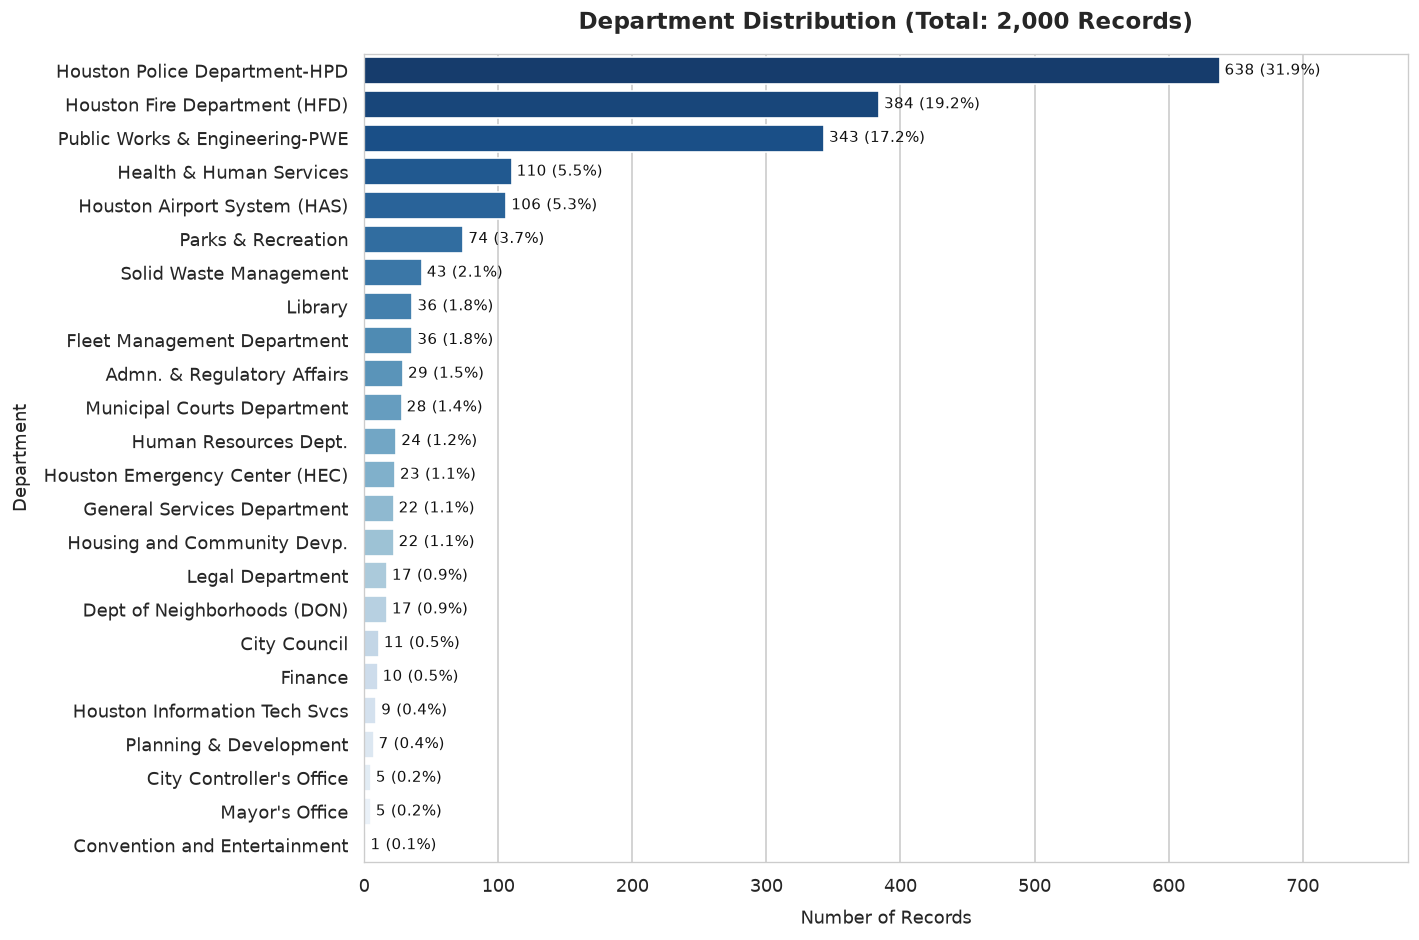

In [9]:
cat1_col = 'department'
cat1_counts = df[cat1_col].value_counts()
plt.figure(figsize=(12, 8))
ax1 = sns.barplot(x=cat1_counts.values, y=cat1_counts.index, hue=cat1_counts.index, palette="Blues_r", legend=False)
for p in ax1.patches:
    w = p.get_width()
    pct = (w / len(df)) * 100
    ax1.annotate(f" {int(w):,} ({pct:.1f}%)", (w, p.get_y() + p.get_height() / 2.),
                 va='center', ha='left', fontsize=9, color='#111111')
plt.title(f"Department Distribution (Total: {len(df):,} Records)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Records", fontsize=11, labelpad=8)
plt.ylabel("Department", fontsize=11, labelpad=8)
plt.xlim(0, max(cat1_counts.values) * 1.22)
plt.tight_layout()
os.makedirs("charts", exist_ok=True)
plt.savefig("charts/1_category_distribution.png", dpi=300)
plt.show()

## 9. Visualization 2: Numerical Comparison by Category
Bar plot showing average base salary across all 24 departments with exact dollar values.

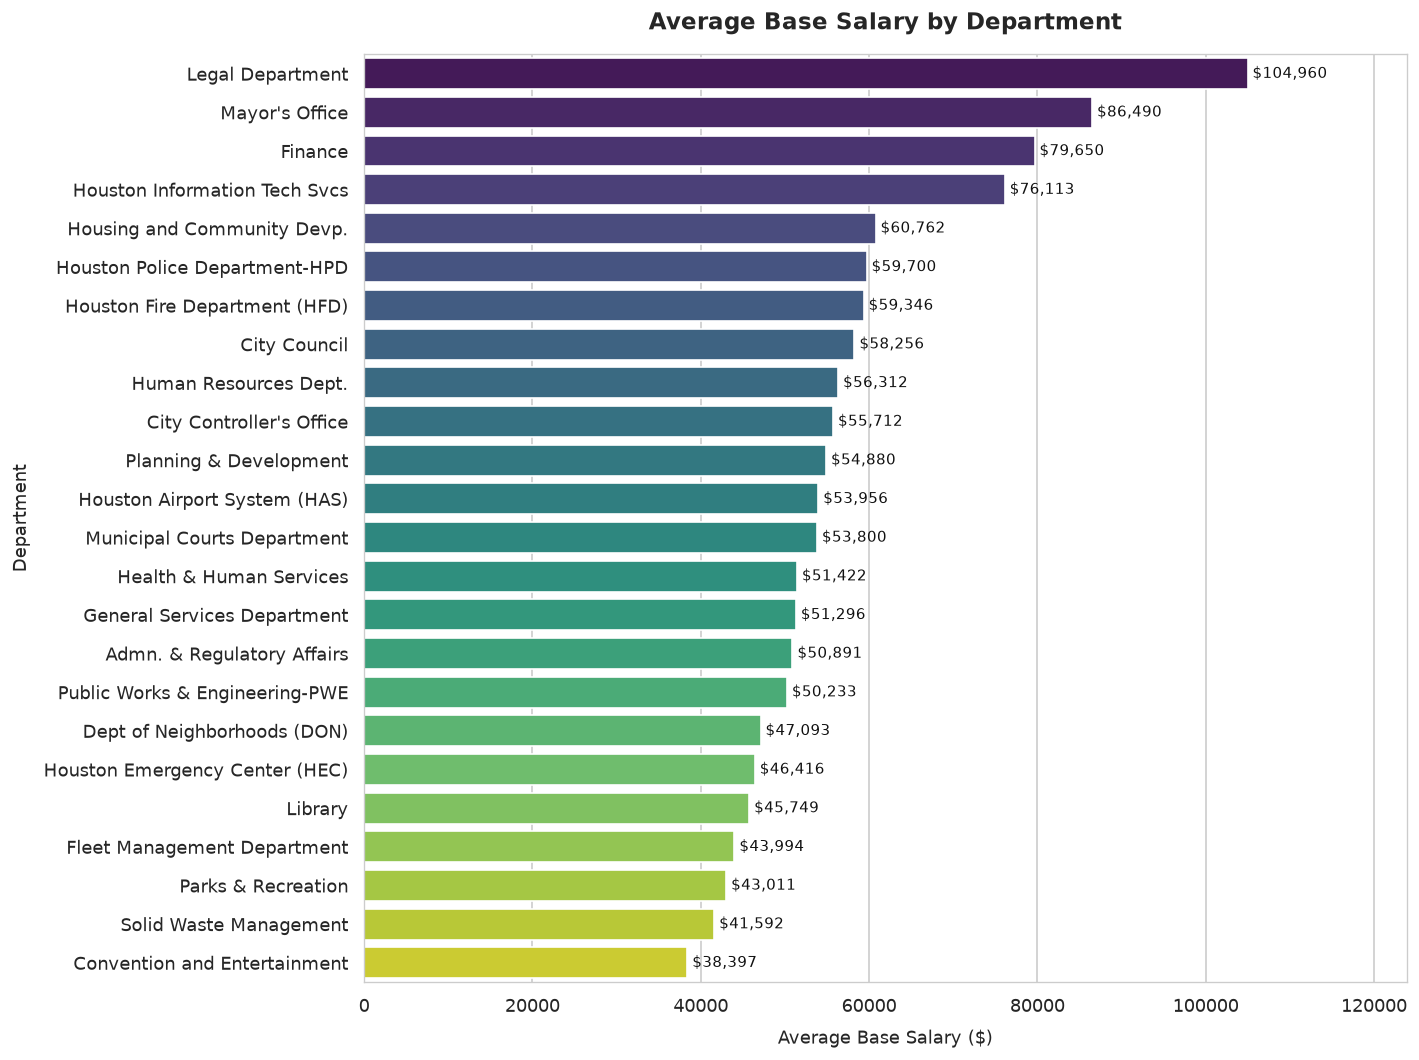

In [10]:
num_col = 'base_salary'
avg_salary = df.groupby('department')[num_col].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 9))
ax2 = sns.barplot(x=avg_salary.values, y=avg_salary.index, hue=avg_salary.index, palette="viridis", legend=False)
for p in ax2.patches:
    w = p.get_width()
    ax2.annotate(f" ${w:,.0f}", (w, p.get_y() + p.get_height() / 2.),
                 va='center', ha='left', fontsize=9, color='#111111')
plt.title("Average Base Salary by Department", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Average Base Salary ($)", fontsize=11, labelpad=8)
plt.ylabel("Department", fontsize=11, labelpad=8)
plt.xlim(0, max(avg_salary.values) * 1.18)
plt.tight_layout()
plt.savefig("charts/2_numerical_comparison.png", dpi=300)
plt.show()

## 10. Visualization 3: Salary Distribution & Central Tendencies
Histogram with KDE curve, reference lines for sample mean and median, and descriptive statistics box.

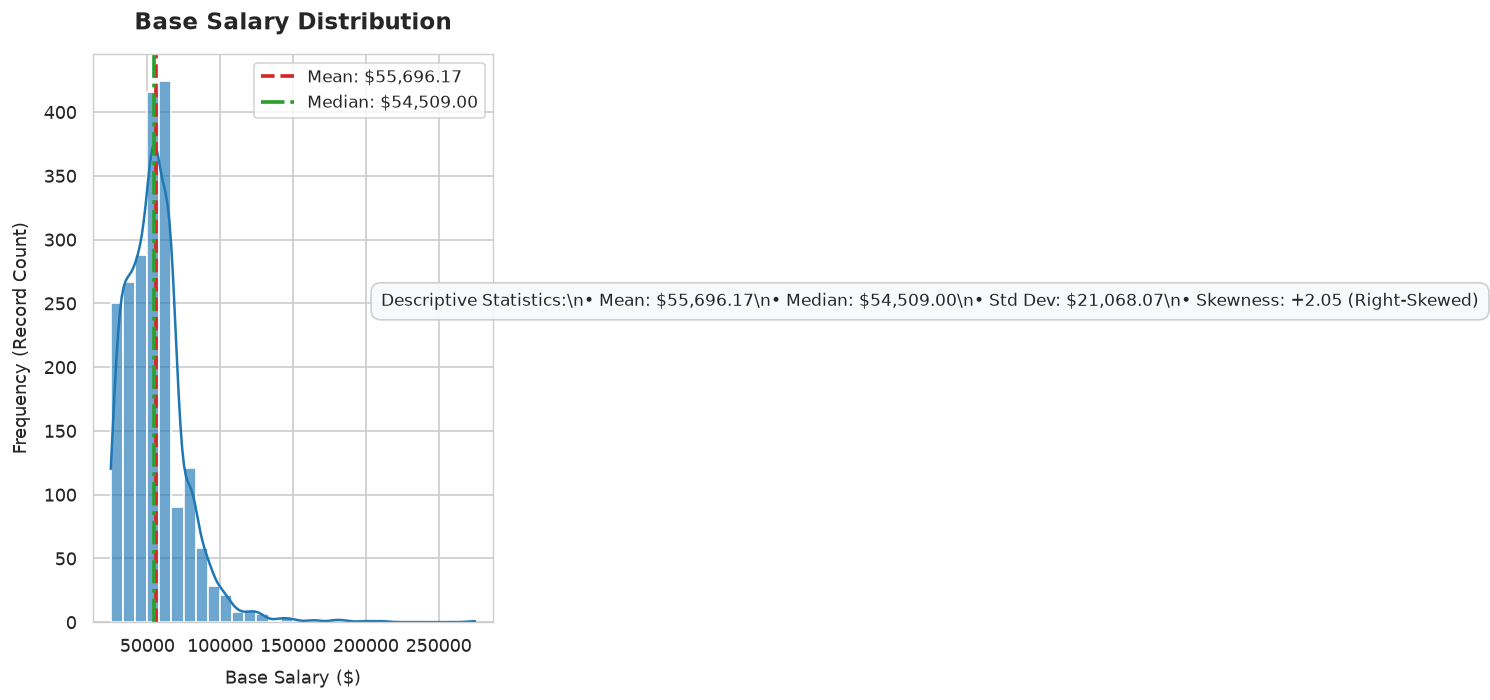

In [11]:
plt.figure(figsize=(11, 6))
mean_val = df['base_salary'].mean()
median_val = df['base_salary'].median()
std_val = df['base_salary'].std()
skew_val = df['base_salary'].skew()

sns.histplot(df['base_salary'], kde=True, bins=30, color="#1f77b4", edgecolor="white", alpha=0.65)
plt.axvline(mean_val, color="#d62728", linestyle="--", linewidth=2.2, label=f"Mean: ${mean_val:,.2f}")
plt.axvline(median_val, color="#2ca02c", linestyle="-.", linewidth=2.2, label=f"Median: ${median_val:,.2f}")

skew_text = "Right-Skewed" if skew_val > 0.2 else ("Left-Skewed" if skew_val < -0.2 else "Symmetric")
stats_box = (
    f"Descriptive Statistics:\n"
    f"• Mean: ${mean_val:,.2f}\n"
    f"• Median: ${median_val:,.2f}\n"
    f"• Std Dev: ${std_val:,.2f}\n"
    f"• Skewness: {skew_val:+.2f} ({skew_text})"
)
plt.gca().text(
    0.72, 0.58, stats_box, transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='#cccccc', alpha=0.95)
)

plt.title("Base Salary Distribution", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Base Salary ($)", fontsize=11, labelpad=8)
plt.ylabel("Frequency (Record Count)", fontsize=11, labelpad=8)
plt.legend(frameon=True, loc="upper right", fontsize=10)
plt.tight_layout()
plt.savefig("charts/3_numerical_distribution.png", dpi=300)
plt.show()

## 11. Visualization 4: Demographic Distribution (Donut Chart)
Donut chart illustrating proportional demographic share with side legend preventing any text collision.

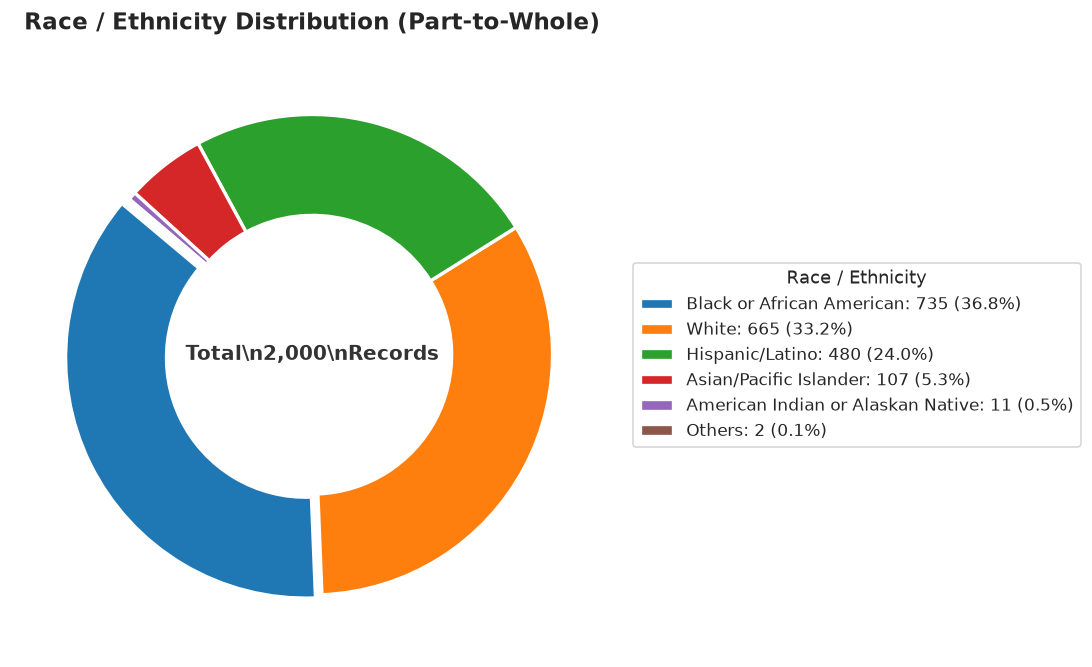

In [12]:
race_counts = df['race'].value_counts()

fig, ax = plt.subplots(figsize=(11, 6.5))
colors = sns.color_palette("tab10")[0:len(race_counts)]
explode = [0.03 if i == 0 else 0 for i in range(len(race_counts))]

wedges, texts = ax.pie(
    race_counts.values,
    explode=explode,
    colors=colors,
    startangle=140,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2)
)

ax.text(0, 0, f"Total\n{len(df):,}\nRecords", ha='center', va='center', fontsize=12, fontweight='bold', color='#333333')

legend_labels = [f"{idx}: {val:,} ({val/len(df)*100:.1f}%)" for idx, val in zip(race_counts.index, race_counts.values)]
ax.legend(
    wedges, legend_labels,
    title="Race / Ethnicity",
    title_fontsize=11,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10,
    frameon=True
)

ax.set_title("Race / Ethnicity Distribution (Part-to-Whole)", fontsize=14, fontweight="bold", pad=15)
plt.savefig("charts/4_part_to_whole.png", dpi=300, bbox_inches='tight')
plt.show()

## 12. Visualization 5: Yearly Hiring Trend Over Time
Longitudinal intake trajectory with callout box highlighting historical peak hiring volume.

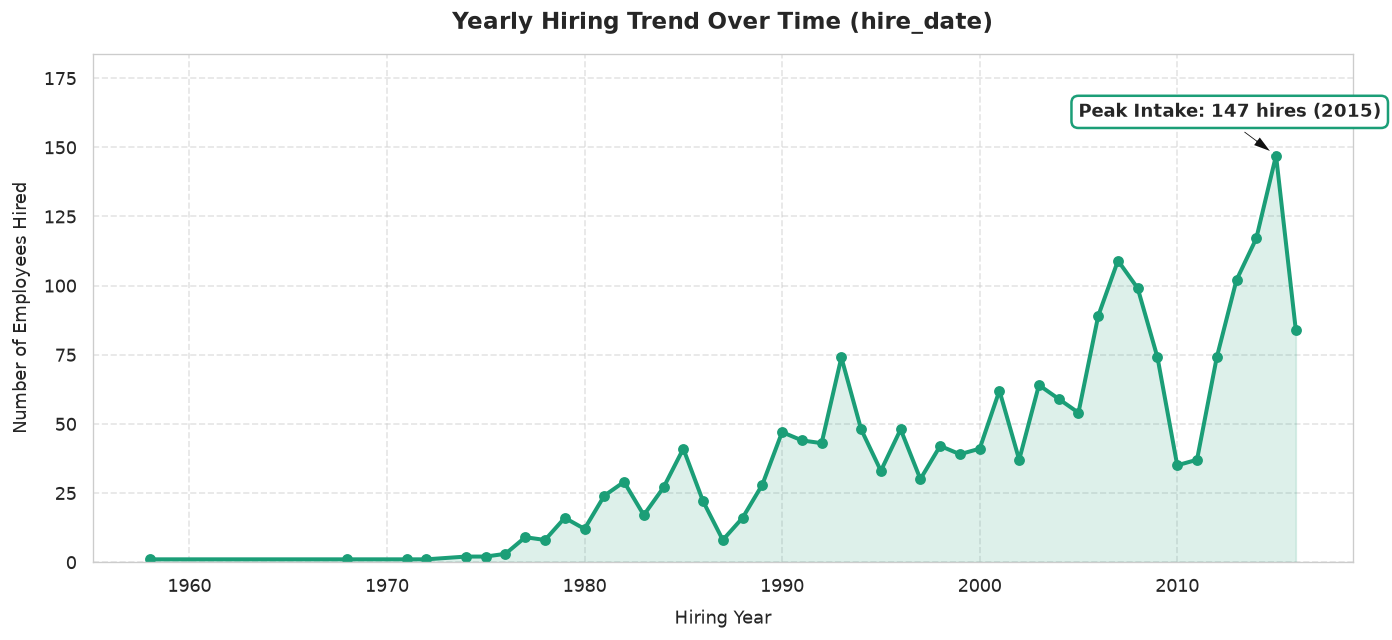

In [13]:
parsed_dates = pd.to_datetime(df['hire_date'], errors="coerce")
valid_years = parsed_dates.dt.year.dropna().astype(int).value_counts().sort_index()
peak_yr = int(valid_years.idxmax())
peak_cnt = int(valid_years.max())

plt.figure(figsize=(12, 5.5))
plt.plot(valid_years.index, valid_years.values, marker="o", markersize=5.5, color="#1b9e77", linewidth=2.4)
plt.fill_between(valid_years.index, valid_years.values, color="#1b9e77", alpha=0.15)

plt.ylim(0, peak_cnt * 1.25)
plt.annotate(
    f"Peak Intake: {peak_cnt:,} hires ({peak_yr})",
    xy=(peak_yr, peak_cnt),
    xytext=(peak_yr - 10, peak_cnt + 14),
    arrowprops=dict(facecolor='#111111', shrink=0.08, width=1.5, headwidth=7),
    fontweight='bold', fontsize=10.5,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#ffffff", edgecolor="#1b9e77", linewidth=1.5)
)

plt.title("Yearly Hiring Trend Over Time (hire_date)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Hiring Year", fontsize=11, labelpad=8)
plt.ylabel("Number of Employees Hired", fontsize=11, labelpad=8)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("charts/5_time_trend.png", dpi=300)
plt.show()

## 13. 5 Business Insights Derived from Dataset
Key empirical findings from statistical analysis and visualization profiling.

In [14]:
insight_1 = (
    "1. Category Volume Concentration: Within the 'department' dimension, "
    "'Houston Police Department-HPD' represents the largest single segment with 638 records, "
    "constituting 31.90% of the total analyzed dataset."
)
insight_2 = (
    "2. Salary Disparity Across Departments: Average base_salary varies significantly across department groups. "
    "The highest average is observed in 'Legal Department' at $104,959.53, "
    "while the lowest average is in 'Convention and Entertainment' at $38,397.00, "
    "representing a 2.73x spread between the highest and lowest functional divisions."
)
insight_3 = (
    "3. Central Tendency & Skewness: The metric 'base_salary' exhibits an overall mean of $55,696.17 "
    "and a median of $54,509.00 (standard deviation: $21,068.07, skewness: +2.05). "
    "Because the mean exceeds the median, the distribution is positively skewed (right-skewed), "
    "reflecting upper-tier executive salaries that elevate the arithmetic average."
)
insight_4 = (
    "4. Workforce Demographic Share: In the 'race' breakdown, the primary classification is "
    "'Black or African American', which comprises 735 records (36.75% of all records), "
    "followed by 'White' with 665 records (33.25%) and 'Hispanic/Latino' with 480 records (24.00%)."
)
insight_5 = (
    "5. Longitudinal Hiring Trajectory: Historical records spanning from 1958 to 2016 reveal that "
    "peak intake under 'hire_date' occurred in calendar year 2015, with 147 records "
    "logged during that twelve-month period."
)

print("=" * 70)
print("[5 BUSINESS INSIGHTS DERIVED FROM DATASET]")
print("=" * 70)
for ins in [insight_1, insight_2, insight_3, insight_4, insight_5]:
    print(ins)
    print("-" * 70)

[5 BUSINESS INSIGHTS DERIVED FROM DATASET]
1. Category Volume Concentration: Within the 'department' dimension, 'Houston Police Department-HPD' represents the largest single segment with 638 records, constituting 31.90% of the total analyzed dataset.
----------------------------------------------------------------------
2. Salary Disparity Across Departments: Average base_salary varies significantly across department groups. The highest average is observed in 'Legal Department' at $104,959.53, while the lowest average is in 'Convention and Entertainment' at $38,397.00, representing a 2.73x spread between the highest and lowest functional divisions.
----------------------------------------------------------------------
3. Central Tendency & Skewness: The metric 'base_salary' exhibits an overall mean of $55,696.17 and a median of $54,509.00 (standard deviation: $21,068.07, skewness: +2.05). Because the mean exceeds the median, the distribution is positively skewed (right-skewed), reflect

## 14. Export Verification

In [15]:
exported_charts = [f for f in os.listdir("charts") if f.endswith(".png")]
print(f"Total Visualizations Exported: {len(exported_charts)}")
for chart in sorted(exported_charts):
    size_kb = os.path.getsize(os.path.join("charts", chart)) / 1024
    print(f"  • {chart} ({size_kb:.1f} KB)")
print("\nAll 15 execution steps completed successfully.")

Total Visualizations Exported: 5
  • 1_category_distribution.png (256.4 KB)
  • 2_numerical_comparison.png (248.8 KB)
  • 3_numerical_distribution.png (282.1 KB)
  • 4_part_to_whole.png (220.5 KB)
  • 5_time_trend.png (218.9 KB)

All 15 execution steps completed successfully.
